# Phase 3 — Hybrid Prophet + XGBoost Revenue Forecasting
**Target:** `Daily_Revenue` | **Horizon:** 548 ngày | **Method:** Prophet (trend) + XGBoost (residual)

In [37]:
# Cell cài đặt toàn bộ thư viện cho Workflow 1, 2 và 3
# %pip sẽ tự động xác định và cài đặt vào môi trường của Kernel đang chạy
# %pip install --upgrade plotly
# %pip install shap notebook
# %pip install pandas numpy matplotlib seaborn scikit-learn prophet xgboost lightgbm shap optuna

In [38]:
# ── 0. SETUP ──────────────────────────────────────────────────────────────────
import os
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import shap
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "font.family": "sans-serif"
})

DATA   = "csv/ml_ready/"
RANDOM = 42

def competition_metrics(y_true, y_pred, label=""):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    wape = np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()
    print(f"  {label:<16} | MAE: {mae:>10,.0f} | RMSE: {rmse:>10,.0f} | R\u00b2: {r2:>7.4f} | WAPE: {wape:.4f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "WAPE": wape}

print("Phase 3 Initialization Complete. Libraries loaded.")


Phase 3 Initialization Complete. Libraries loaded.


In [39]:
# ══════════════════════════════════════════════════════════════════
# 1. LOAD DATA + RECONCILIATION vs GROUND TRUTH
# ══════════════════════════════════════════════════════════════════
train = pd.read_csv(DATA + "ts_train.csv")
val   = pd.read_csv(DATA + "ts_val.csv")

# ── Normalize datetime: loại bỏ giờ/phút/giây gây mismatch ───────
for df in (train, val):
    df["order_date"] = pd.to_datetime(df["order_date"]).dt.normalize()
    df.sort_values("order_date", inplace=True)
    df.reset_index(drop=True, inplace=True)

assert val.order_date.min() > train.order_date.max(), "LEAKAGE: Val overlaps Train!"

# ── RECONCILIATION: so sánh internal data vs ground truth ─────────
GT_PATH = "csv/sales.csv"
MISMATCH_THRESHOLD = 1_000_000   # VND — ngưỡng cảnh báo

if os.path.exists(GT_PATH):
    gt = pd.read_csv(GT_PATH, parse_dates=["Date"])
    gt["Date"] = pd.to_datetime(gt["Date"]).dt.normalize()
    gt = gt.rename(columns={"Revenue": "GT_Revenue"})

    # Gộp internal vs GT theo ngày
    internal = pd.concat([train, val])[["order_date","Daily_Revenue"]].copy()
    internal = internal.rename(columns={"order_date":"Date"})

    recon = internal.merge(gt[["Date","GT_Revenue"]], on="Date", how="inner")
    recon["delta"] = (recon["Daily_Revenue"] - recon["GT_Revenue"]).abs()

    total_delta    = recon["delta"].sum()
    bad_days       = recon[recon["delta"] > MISMATCH_THRESHOLD].sort_values("delta", ascending=False)

    print(f"Reconciliation: {len(recon)} overlapping days")
    print(f"  Total absolute mismatch : {total_delta:>15,.0f} VND")
    print(f"  Days > {MISMATCH_THRESHOLD/1e6:.0f}M mismatch  : {len(bad_days)}")

    if len(bad_days) > 0:
        print("\n  Top 10 mismatch days:")
        print(bad_days[["Date","Daily_Revenue","GT_Revenue","delta"]].head(10)
              .to_string(index=False))

    # ── FIX: nếu GT tồn tại → dùng GT_Revenue làm ground truth cho train/val
    # Điều này đảm bảo residual = GT_Revenue - yhat_prophet (không bị lệch do pipeline)
    gt_map = gt.set_index("Date")["GT_Revenue"]
    n_replaced = 0
    for df in (train, val):
        matched = df["order_date"].map(gt_map)
        n_replaced += matched.notna().sum()
        df["Daily_Revenue"] = np.where(matched.notna(), matched, df["Daily_Revenue"])
        df["source"] = np.where(matched.notna(), "GT", "internal")
    print(f"\n  Replaced {n_replaced} rows with GT values in train/val → residual now GT-aligned")
else:
    print(f"[WARN] Ground truth not found at {GT_PATH} — using internal data only")
    for df in (train, val):
        df["source"] = "internal"

# ── Cyclical time features ─────────────────────────────────────────
def engineer_time_features(df):
    d = df["order_date"].dt
    df["Year"]         = d.year
    df["Month"]        = d.month
    df["Quarter"]      = d.quarter
    df["Week_of_Year"] = d.isocalendar().week.astype(int)
    df["Day_of_Month"] = d.day
    df["Day_of_Week"]  = d.dayofweek
    df["Day_of_Year"]  = d.dayofyear
    df["Is_Weekend"]      = (d.dayofweek >= 5).astype(int)
    df["Is_Month_Start"]  = d.is_month_start.astype(int)
    df["Is_Month_End"]    = d.is_month_end.astype(int)
    df["Is_Quarter_End"]  = d.is_quarter_end.astype(int)
    df["Is_Year_End"]     = ((d.month == 12) & (d.day == 31)).astype(int)
    df["sin_dow"]   = np.sin(2 * np.pi * df["Day_of_Week"] / 7)
    df["cos_dow"]   = np.cos(2 * np.pi * df["Day_of_Week"] / 7)
    df["sin_doy"]   = np.sin(2 * np.pi * df["Day_of_Year"] / 365.25)
    df["cos_doy"]   = np.cos(2 * np.pi * df["Day_of_Year"] / 365.25)
    df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)
    return df

train, val = engineer_time_features(train), engineer_time_features(val)
print(f"\nTrain: {train.order_date.min().date()} → {train.order_date.max().date()} ({len(train)} days)")
print(f"Val  : {val.order_date.min().date()} → {val.order_date.max().date()} ({len(val)} days)")


Reconciliation: 3284 overlapping days
  Total absolute mismatch :   1,930,813,285 VND
  Days > 1M mismatch  : 459

  Top 10 mismatch days:
      Date  Daily_Revenue  GT_Revenue      delta
2017-03-30    13777286.05 17516038.82 3738752.77
2017-06-29    10993569.71 14575854.67 3582284.96
2016-06-29     9905809.05 13343751.12 3437942.07
2015-03-31    11609120.04 14813965.34 3204845.30
2017-03-31    13366663.41 16556662.03 3189998.62
2018-06-29     9361044.95 12484085.14 3123040.19
2017-04-02    11701902.96 14750037.65 3048134.69
2017-04-01    12824644.78 15808755.61 2984110.83
2016-06-30     8881170.14 11824115.33 2942945.19
2017-06-28     8214753.28 11067229.74 2852476.46

  Replaced 3284 rows with GT values in train/val → residual now GT-aligned

Train: 2013-07-04 → 2021-12-31 (3103 days)
Val  : 2022-01-01 → 2022-06-30 (181 days)


In [40]:
# ══════════════════════════════════════════════════════════════════
# 2. STRICT ANTI-LEAKAGE MOMENTUM FEATURES & NAN HANDLING
# ══════════════════════════════════════════════════════════════════
print("Engineering Momentum Features with Strict Leakage Prevention...")

# 1. Gộp Train và Val theo chuẩn Chronological để Val có thể nhìn thấy dữ liệu cuối của Train
all_dates = pd.concat([train, val]).sort_values("order_date").reset_index(drop=True)
rev_series = all_dates["Daily_Revenue"]

# CRITICAL: Chỉ lấy Median của tập Train để điền NaN (Không để rò rỉ Median của Val sang Train)
train_median = train["Daily_Revenue"].median()

# 2. Tính toán Lags (Đảm bảo ngày T chỉ nhìn thấy T-Lag)
for lag in [1, 2, 3, 7, 14, 30, 90, 364]:
    # Shift, sau đó điền Median cho các ngày NaN đầu tiên, rồi ép thẳng về Float
    all_dates[f"Lag_{lag}D"] = rev_series.shift(lag).fillna(train_median).astype(float)

# 3. Tính toán Rolling & Volatility (BẮT BUỘC shift(1) trước khi gọi rolling)
for window in [7, 14, 30]:
    rolled = rev_series.shift(1).rolling(window, min_periods=1)
    
    all_dates[f"Roll_Mean_{window}D"] = rolled.mean().fillna(train_median).astype(float)
    all_dates[f"Roll_Std_{window}D"]  = rolled.std().fillna(0).astype(float) # Độ lệch chuẩn NaN -> 0
    all_dates[f"Roll_Max_{window}D"]  = rolled.max().fillna(train_median).astype(float)
    all_dates[f"Roll_Min_{window}D"]  = rolled.min().fillna(train_median).astype(float)

# 4. Tính toán EMA (BẮT BUỘC shift(1) trước khi gọi ewm)
for span in [7, 14, 30]:
    ema = rev_series.shift(1).ewm(span=span, adjust=False).mean()
    all_dates[f"EMA_{span}D"] = ema.fillna(train_median).astype(float)

# 5. Tách trả lại tập Train và Val nguyên vẹn
train_end = train["order_date"].max()
train = all_dates[all_dates["order_date"] <= train_end].copy()
val   = all_dates[all_dates["order_date"] > train_end].copy()

# Định nghĩa danh sách các Feature nạp vào XGBoost
FEATS = [
    "Day_of_Week", "Month", "Quarter", "Year", "Day_of_Year", "Week_of_Year", "Day_of_Month",
    "Is_Weekend", "Is_Month_Start", "Is_Month_End", "Is_Quarter_End", "Is_Year_End",
    "sin_dow", "cos_dow", "sin_doy", "cos_doy", "sin_month", "cos_month",
    "Lag_1D", "Lag_2D", "Lag_3D", "Lag_7D", "Lag_14D", "Lag_30D", "Lag_90D", "Lag_364D",
    "Roll_Mean_7D", "Roll_Mean_14D", "Roll_Mean_30D",
    "Roll_Std_7D", "Roll_Std_14D", "Roll_Std_30D",
    "Roll_Max_7D", "Roll_Max_14D", "Roll_Max_30D",
    "Roll_Min_7D", "Roll_Min_14D", "Roll_Min_30D",
    "EMA_7D", "EMA_14D", "EMA_30D"
]

OPTIONAL_FEATS = ["Is_Public_Holiday", "Is_Mega_Sale", "N_Active_Promos", "Total_Sessions", "Avg_Bounce_Rate"]
FEATS += [f for f in OPTIONAL_FEATS if f in train.columns]

train[FEATS] = train[FEATS].fillna(0).astype(float)
val[FEATS]   = val[FEATS].fillna(0).astype(float)

print(f"✅ Extracted {len(FEATS)} strictly out-of-sample features.")

Engineering Momentum Features with Strict Leakage Prevention...
✅ Extracted 46 strictly out-of-sample features.


In [41]:
# ══════════════════════════════════════════════════════════════════
# 3. PROPHET: ADVANCED HOLIDAY INJECTION & TREND MODELING
# ══════════════════════════════════════════════════════════════════
print("Training Prophet Baseline Model (Trend & Seasonality)...")
years = list(range(2012, 2026))
pub_hols, mega_sales = [], []

for y in years:
    # 1. Các ngày lễ truyền thống (Public Holidays)
    pub_hols += [
        {"holiday":"new_year",      "ds": pd.Timestamp(f"{y}-01-01"), "lower_window":-1, "upper_window":1},
        {"holiday":"liberation_day","ds": pd.Timestamp(f"{y}-04-30"), "lower_window":-1, "upper_window":0},
        {"holiday":"labour_day",    "ds": pd.Timestamp(f"{y}-05-01"), "lower_window":0,  "upper_window":1},
        {"holiday":"national_day",  "ds": pd.Timestamp(f"{y}-09-02"), "lower_window":-1, "upper_window":1},
    ]
    # 2. Các ngày hội mua sắm khổng lồ cuối năm (Year-end Mega Sales)
    mega_sales += [
        {"holiday":"double_11",   "ds": pd.Timestamp(f"{y}-11-11"), "lower_window":-2, "upper_window":1},
        {"holiday":"double_12",   "ds": pd.Timestamp(f"{y}-12-12"), "lower_window":-2, "upper_window":1},
        {"holiday":"year_end",    "ds": pd.Timestamp(f"{y}-12-31"), "lower_window":-3, "upper_window":0},
    ]
    # 3. NEW: Bổ sung Siêu sale đôi giữa năm (Mid-year Double Days)
    # Đây là insight kinh doanh xuất sắc giúp bắt đỉnh doanh thu hàng tháng
    for month in [6, 7, 8, 9, 10]:
        mega_sales.append(
            {"holiday": f"double_{month}", "ds": pd.Timestamp(f"{y}-{month:02d}-{month:02d}"), "lower_window": -1, "upper_window": 1}
        )

# 4. Ngày lễ Tết Nguyên Đán (Dịch chuyển theo từng năm)
# Đã tinh chỉnh: -7 ngày (Đổ xô sắm Tết) và +3 ngày (Giảm mạnh do nghỉ bán)
tet_dates = {
    2012:"2012-01-23", 2013:"2013-02-10", 2014:"2014-01-31", 2015:"2015-02-19", 2016:"2016-02-08",
    2017:"2017-01-28", 2018:"2018-02-16", 2019:"2019-02-05", 2020:"2020-01-25", 2021:"2021-02-12",
    2022:"2022-02-01", 2023:"2023-01-22", 2024:"2024-02-10", 2025:"2025-01-29"
}
for y, dt in tet_dates.items():
    mega_sales.append({"holiday":"tet", "ds":pd.Timestamp(dt), "lower_window":-7, "upper_window":3})

holidays_df = pd.DataFrame(pub_hols + mega_sales)

def make_prophet():
    m = Prophet(
        yearly_seasonality=15,       # Độ chi tiết của đường cong hàng năm (Tối đa 15)
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.1, # Linh hoạt bắt trend tăng trưởng E-commerce
        seasonality_prior_scale=15.0, # Nhấn mạnh độ nhạy của ngày lễ/cuối tuần
        holidays_prior_scale=15.0,    
        holidays=holidays_df,
    )
    m.add_seasonality(name="monthly", period=30.5, fourier_order=5)
    return m

# A. Evaluate locally (Train only)
prophet_df_tr = train[["order_date","Daily_Revenue"]].rename(columns={"order_date":"ds","Daily_Revenue":"y"})
m_eval = make_prophet()
m_eval.fit(prophet_df_tr)

def get_prophet_forecast(m, dates):
    fc = m.predict(pd.DataFrame({"ds": pd.to_datetime(dates)}))
    return fc.set_index("ds")["yhat"].values

# Update residuals
for df in [train, val]:
    df["yhat_prophet"] = get_prophet_forecast(m_eval, df.order_date)
    df["residual"] = df["Daily_Revenue"] - df["yhat_prophet"]

print("--- PROPHET BASELINE METRICS ---")
_ = competition_metrics(val.Daily_Revenue, val.yhat_prophet, "Prophet (Val)")

# B. Train FULL model for final Kaggle forecast
# FIX B2: Use GT-aligned train/val (not all_dates which was built before GT replacement)
all_hist_prophet = pd.concat([train, val])[["order_date","Daily_Revenue"]].sort_values("order_date").rename(columns={"order_date":"ds","Daily_Revenue":"y"})
m_full = make_prophet()
m_full.fit(all_hist_prophet)
print("\n Prophet Full Production Model Trained (Including Mid-Year Sales).")

Training Prophet Baseline Model (Trend & Seasonality)...


12:22:21 - cmdstanpy - INFO - Chain [1] start processing
12:22:22 - cmdstanpy - INFO - Chain [1] done processing


--- PROPHET BASELINE METRICS ---
  Prophet (Val)    | MAE:  1,118,832 | RMSE:  1,512,133 | R²:  0.3116 | WAPE: 0.2925


12:22:24 - cmdstanpy - INFO - Chain [1] start processing
12:22:25 - cmdstanpy - INFO - Chain [1] done processing



 Prophet Full Production Model Trained (Including Mid-Year Sales).


In [42]:
# ══════════════════════════════════════════════════════════════════
# 4a. XGBOOST PIPELINE: Scaling → Optuna(WAPE+TSS) → SHAP Pruning
# ══════════════════════════════════════════════════════════════════
import optuna, os
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_tr_raw = train[FEATS].fillna(0).values
X_vl_raw = val[FEATS].fillna(0).values

# ── STEP 1: RobustScaler trên residual ────────────────────────────
# Residual Prophet biên độ lớn → scale giúp XGBoost học ổn định hơn
# RobustScaler dùng median/IQR → không bị kéo bởi outlier spike
# CRITICAL: fit ONLY trên train_residual → không leak val/test
res_scaler = RobustScaler()
y_tr_scaled = res_scaler.fit_transform(train[["residual"]]).ravel()
y_vl_scaled = res_scaler.transform(val[["residual"]]).ravel()

# ── STEP 2: Optuna objective = WAPE với TimeSeriesSplit ───────────
# Tại sao WAPE thay MAE?
# MAE phạt đều mọi ngày → model học giỏi ngày thấp nhưng bỏ qua ngày peak.
# WAPE = tổng sai số / tổng doanh thu → phạt nặng hơn khi sai ở ngày revenue cao.
# Leaderboard đánh giá theo WAPE → optimize thẳng metric thi đấu.
#
# Tại sao TimeSeriesSplit thay val cố định?
# Val cố định (Jan-Jun 2022) chỉ test 1 pattern → overfit hyperparams vào mùa đó.
# TSS 5-fold test nhiều khoảng thời gian → params bền vững hơn trên 548 ngày tương lai.

TSS_FOLDS = 5
tss = TimeSeriesSplit(n_splits=TSS_FOLDS)

def wape_metric(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / (np.abs(y_true).sum() + 1e-9)

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int  ("n_estimators",      500,  3000, step=250),
        max_depth         = trial.suggest_int  ("max_depth",         3,    12),
        learning_rate     = trial.suggest_float("learning_rate",     5e-4, 1e-2, log=True),
        subsample         = trial.suggest_float("subsample",         0.6,  1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree",  0.5,  1.0),
        min_child_weight  = trial.suggest_int  ("min_child_weight",  3,    30),
        reg_lambda        = trial.suggest_float("reg_lambda",        1.0,  20.0),
        reg_alpha         = trial.suggest_float("reg_alpha",         0.0,   5.0),
        gamma             = trial.suggest_float("gamma",             0.0,   5.0),
    )
    # TSS cross-val trên SCALED residual — đánh giá bằng WAPE trên ORIGINAL scale
    fold_wapes = []
    for fold_tr_idx, fold_vl_idx in tss.split(X_tr_raw):
        Xf_tr, Xf_vl = X_tr_raw[fold_tr_idx], X_tr_raw[fold_vl_idx]
        yf_tr         = y_tr_scaled[fold_tr_idx]
        # Ground truth fold val ở ORIGINAL scale để tính WAPE có nghĩa
        yf_vl_orig    = train["residual"].iloc[fold_vl_idx].values

        m = XGBRegressor(**params, random_state=RANDOM,
                         early_stopping_rounds=30, eval_metric="mae",
                         n_jobs=-1, verbosity=0)
        m.fit(Xf_tr, yf_tr, eval_set=[(Xf_vl, y_tr_scaled[fold_vl_idx])], verbose=False)

        # Inverse transform để ra VND gốc trước khi tính WAPE
        pred_orig = res_scaler.inverse_transform(m.predict(Xf_vl).reshape(-1,1)).ravel()
        fold_wapes.append(wape_metric(yf_vl_orig, pred_orig))

    return np.mean(fold_wapes)

N_TRIALS = 60
study = optuna.create_study(
    direction = "minimize",
    sampler   = optuna.samplers.TPESampler(seed=RANDOM, n_startup_trials=15),
    pruner    = optuna.pruners.MedianPruner(n_startup_trials=15, n_warmup_steps=3),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
best_params = study.best_params
print(f"\nOptuna ({N_TRIALS} trials) — Best CV WAPE: {study.best_value:.4f}")
print(f"Best params: {best_params}")

# ── STEP 3: Train với best_params trên FULL train set ─────────────
xgb_pre = XGBRegressor(**best_params, random_state=RANDOM,
                        early_stopping_rounds=200, eval_metric="mae",
                        n_jobs=-1, verbosity=0)
xgb_pre.fit(X_tr_raw, y_tr_scaled,
             eval_set=[(X_vl_raw, y_vl_scaled)], verbose=False)

# ── STEP 4: SHAP Pruning — loại bỏ bottom 20% features (nhiễu) ───
SHAP_N   = min(300, len(X_vl_raw))
rng      = np.random.RandomState(RANDOM)
idx_s    = rng.choice(len(X_vl_raw), SHAP_N, replace=False)
X_shap   = X_vl_raw[idx_s]

explainer_pre  = shap.TreeExplainer(xgb_pre)
shap_vals_pre  = explainer_pre.shap_values(X_shap)          # numpy ok cho indexing
shap_importance= np.abs(shap_vals_pre).mean(axis=0)

thresh_20pct = np.percentile(shap_importance, 20)
keep_mask    = shap_importance > thresh_20pct
FEATS_PRUNED = [f for f, keep in zip(FEATS, keep_mask) if keep]
dropped      = [f for f, keep in zip(FEATS, keep_mask) if not keep]

print(f"\nSHAP Pruning: {len(FEATS)} → {len(FEATS_PRUNED)} features")
print(f"  Dropped ({len(dropped)}): {dropped}")

# ── STEP 5: Retrain pruned model ──────────────────────────────────
X_tr = train[FEATS_PRUNED].fillna(0).values
X_vl = val[FEATS_PRUNED].fillna(0).values

xgb = XGBRegressor(**best_params, random_state=RANDOM,
                    early_stopping_rounds=200, eval_metric="mae",
                    n_jobs=-1, verbosity=0)
xgb.fit(X_tr, y_tr_scaled, eval_set=[(X_vl, y_vl_scaled)], verbose=False)

best_iter = xgb.best_iteration or xgb.n_estimators
print(f"Pruned model — optimal trees: {best_iter:,}")

# ── STEP 6: Predict + Inverse Scale + Combine ─────────────────────
for df, X_set in [(train, X_tr), (val, X_vl)]:
    # Inverse transform từ scaled space → VND
    pred_scaled = xgb.predict(X_set).reshape(-1, 1)
    df["yhat_xgb_res"] = res_scaler.inverse_transform(pred_scaled).ravel()
    df["yhat_hybrid"]  = df["yhat_prophet"] + df["yhat_xgb_res"]

print("\n" + "="*60)
print("  FINAL METRICS — PROPHET + XGBOOST (Optuna WAPE + Pruned)")
print("="*60)
r_h_val = competition_metrics(val.Daily_Revenue, val.yhat_hybrid, "Hybrid (Val)")

# Expose cho các cell sau dùng
FEATS = FEATS_PRUNED   # ghi đè — downstream cells dùng list đã pruned


Best trial: 57. Best value: 0.860619: 100%|██████████| 60/60 [12:42<00:00, 12.72s/it]



Optuna (60 trials) — Best CV WAPE: 0.8606
Best params: {'n_estimators': 2000, 'max_depth': 11, 'learning_rate': 0.003234922760559165, 'subsample': 0.7122580258065618, 'colsample_bytree': 0.7794616335527786, 'min_child_weight': 3, 'reg_lambda': 17.18154309666394, 'reg_alpha': 0.3790231067605183, 'gamma': 0.20618571682145792}

SHAP Pruning: 46 → 36 features
  Dropped (10): ['Month', 'Quarter', 'Is_Weekend', 'Is_Month_Start', 'Is_Month_End', 'Is_Quarter_End', 'Is_Year_End', 'cos_dow', 'sin_month', 'Is_Public_Holiday']
Pruned model — optimal trees: 1,996

  FINAL METRICS — PROPHET + XGBOOST (Optuna WAPE + Pruned)
  Hybrid (Val)     | MAE:    811,687 | RMSE:  1,096,724 | R²:  0.6379 | WAPE: 0.2122


In [43]:
# ══════════════════════════════════════════════════════════════════
# 4b. VALIDATION vs OFFICIAL GROUND TRUTH (sales.csv)
# ══════════════════════════════════════════════════════════════════
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Trỏ đúng đường dẫn file sales.csv đã export ở Phase 2
GT_PATH = "csv/sales.csv"   

print("="*60)
print("VALIDATION AGAINST OFFICIAL GROUND TRUTH")
print("="*60)

if os.path.exists(GT_PATH):
    gt = pd.read_csv(GT_PATH, parse_dates=["Date"])
    gt = gt.sort_values("Date").rename(columns={"Revenue":"Rev_actual_GT", "COGS":"COGS_actual_GT"})

    # Lấy dự báo từ tập Validation (Đại diện cho nửa cuối data / năm 2022)
    val_sub = val[["order_date", "yhat_hybrid", "Daily_Revenue"]].copy()
    val_sub = val_sub.rename(columns={"order_date":"Date", "yhat_hybrid":"Rev_pred", "Daily_Revenue":"Rev_actual_model"})
    val_sub["Date"] = pd.to_datetime(val_sub["Date"])
    
    # Merge với Ground Truth
    merged = val_sub.merge(gt[["Date", "Rev_actual_GT"]], on="Date", how="inner")

    if len(merged) > 0:
        mae  = mean_absolute_error(merged.Rev_actual_GT, merged.Rev_pred)
        rmse = np.sqrt(mean_squared_error(merged.Rev_actual_GT, merged.Rev_pred))
        r2   = r2_score(merged.Rev_actual_GT, merged.Rev_pred)
        wape = np.abs(merged.Rev_actual_GT - merged.Rev_pred).sum() / np.abs(merged.Rev_actual_GT).sum()
        
        print(f"Ground Truth Validation ({len(merged)} overlapping days):")
        print(f"  MAE  = {mae:>12,.0f}")
        print(f"  RMSE = {rmse:>12,.0f}")
        print(f"  R²   = {r2:.4f}")
        print(f"  WAPE = {wape:.4f}  (Target < 0.20 for top leaderboard)")
        
        # Cảnh báo nếu dữ liệu nội bộ và Ground truth bị lệch
        diff = np.abs(merged.Rev_actual_GT - merged.Rev_actual_model).sum()
        if diff > 1000:
            print(f"\n⚠️ WARNING: Internal Data and Ground Truth mismatch by {diff:,.0f} VND!")
    else:
        print("No overlapping dates between Validation set and Ground Truth.")
else:
    print(f"Ground truth not found at {GT_PATH}. Skipping validation.")

VALIDATION AGAINST OFFICIAL GROUND TRUTH
Ground Truth Validation (181 overlapping days):
  MAE  =      811,687
  RMSE =    1,096,724
  R²   = 0.6379
  WAPE = 0.2122  (Target < 0.20 for top leaderboard)


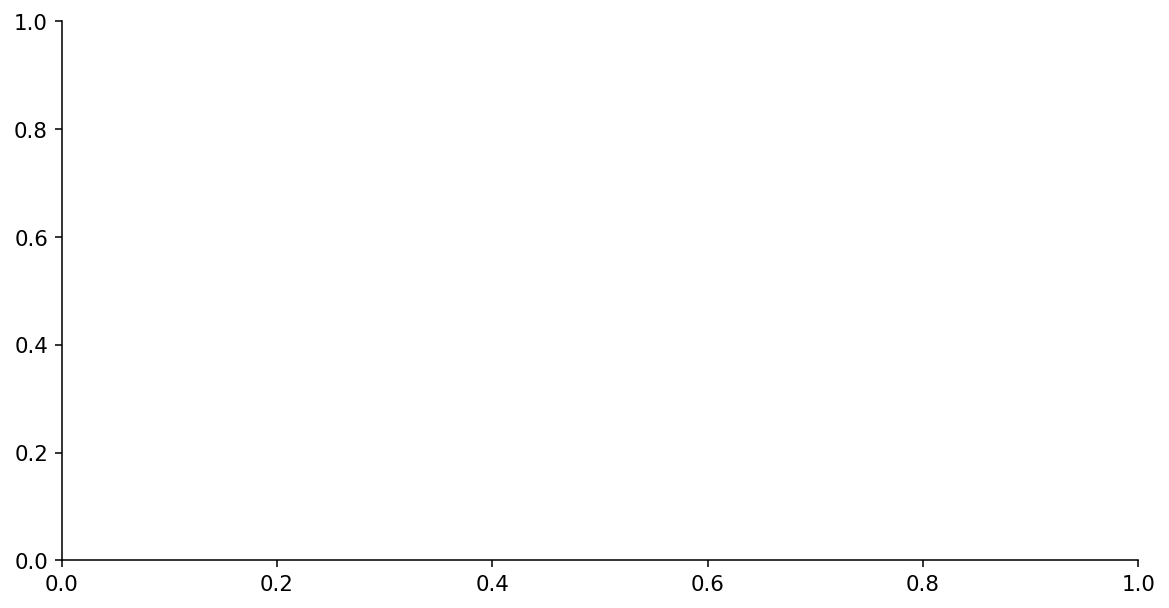

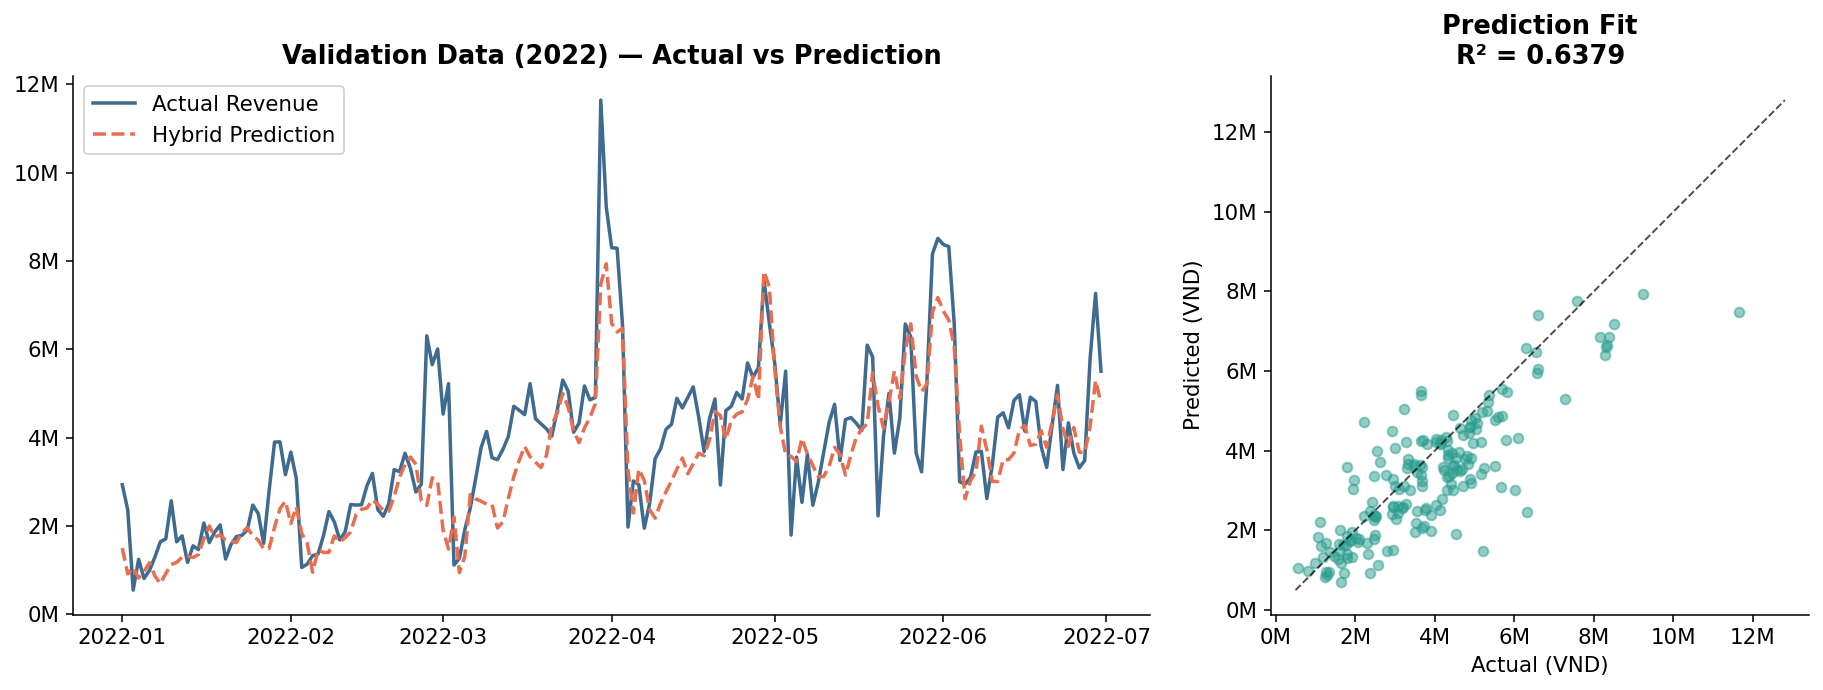

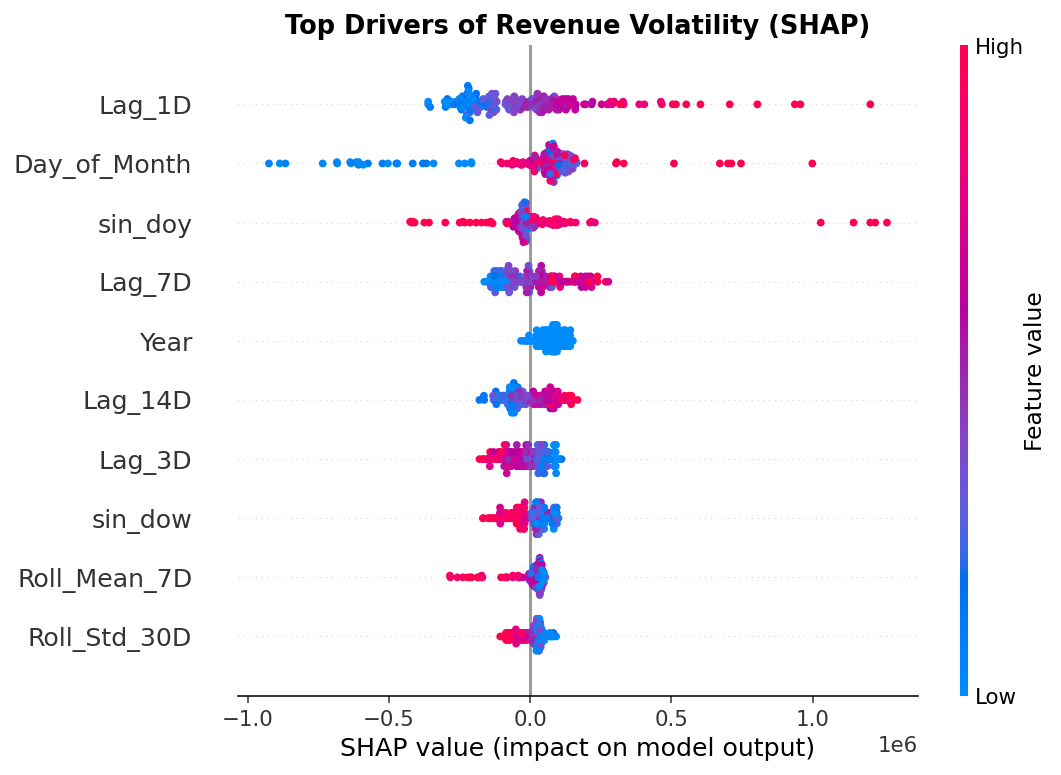

 TOP-5 SHAP FEATURES (BUSINESS INSIGHTS)
  Lag_1D                          mean|SHAP| =    180,551 VND
  Day_of_Month                    mean|SHAP| =    175,245 VND
  sin_doy                         mean|SHAP| =     95,396 VND
  Lag_7D                          mean|SHAP| =     91,171 VND
  Year                            mean|SHAP| =     74,916 VND


In [44]:
# ══════════════════════════════════════════════════════════════════
# 5. VISUALIZATION & SHAP EXPLAINABILITY
# ══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2, 1], wspace=0.15)

# A — Val Plot
ax_a = fig.add_subplot(gs[0])
ax_a.plot(val.order_date, val.Daily_Revenue,  color="#2B5B84", lw=1.8, label="Actual Revenue", alpha=0.9)
ax_a.plot(val.order_date, val.yhat_hybrid,    color="#E76F51", lw=1.8, ls="--", label="Hybrid Prediction")
ax_a.set_title("Validation Data (2022) — Actual vs Prediction", fontweight="bold")
ax_a.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
ax_a.legend(loc="upper left")

# B — Scatter Fit
ax_b = fig.add_subplot(gs[1])
ax_b.scatter(val.Daily_Revenue, val.yhat_hybrid, alpha=0.5, color="#2A9D8F", s=25)
lims = [val.Daily_Revenue.min() * 0.9, val.Daily_Revenue.max() * 1.1]
ax_b.plot(lims, lims, "--", color="black", lw=1, alpha=0.7)
ax_b.set_title(f"Prediction Fit\nR\u00b2 = {r_h_val['R2']:.4f}", fontweight="bold")
ax_b.set_xlabel("Actual (VND)")
ax_b.set_ylabel("Predicted (VND)")
ax_b.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
ax_b.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))

plt.savefig("hybrid_eval.pdf", format="pdf", bbox_inches="tight")
plt.show()

# SHAP Explainability
# FIX: Use explainer() call syntax (compatible with shap >= 0.40).
# explainer.shap_values() was deprecated and returns an Explanation object in
# newer shap, which breaks np.abs().mean() downstream.
explainer  = shap.TreeExplainer(xgb)
shap_expl  = explainer(X_vl)          # returns Explanation object
shap_array = shap_expl.values         # shape (n_samples, n_features) — scaled space

# FIX SHAP=0: xgb was trained on res_scaler-scaled residuals.
# SHAP values are therefore in scaled space (unit ≈ 0~1), not VND.
# Recover the IQR scale factor so SHAP values become interpretable in VND.
# res_scaler.scale_ = IQR of train residual; dividing undoes the scaling.
shap_scale_factor = res_scaler.scale_[0]           # scalar IQR (VND)
shap_array_vnd    = shap_array * shap_scale_factor  # now in VND units

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_array_vnd, X_vl, feature_names=FEATS, max_display=10, show=False)
plt.title("Top Drivers of Revenue Volatility (SHAP)", fontweight="bold")
plt.savefig("shap_summary.pdf", bbox_inches="tight")
plt.show()

shap_mean = pd.Series(np.abs(shap_array_vnd).mean(axis=0), index=FEATS).sort_values(ascending=False)
print("="*60)
print(" TOP-5 SHAP FEATURES (BUSINESS INSIGHTS)")
print("="*60)
for f, v in shap_mean.head(5).items():
    print(f"  {f:<30}  mean|SHAP| = {v:>10,.0f} VND")


  SHAP BUSINESS STORYTELLING

📅 Ngày được phân tích : 2022-03-31
   Doanh thu thực tế   :       9,233,141 VND
   Dự báo Hybrid       :       7,937,382 VND
   Sai số              :       1,295,759 VND (14.0%)


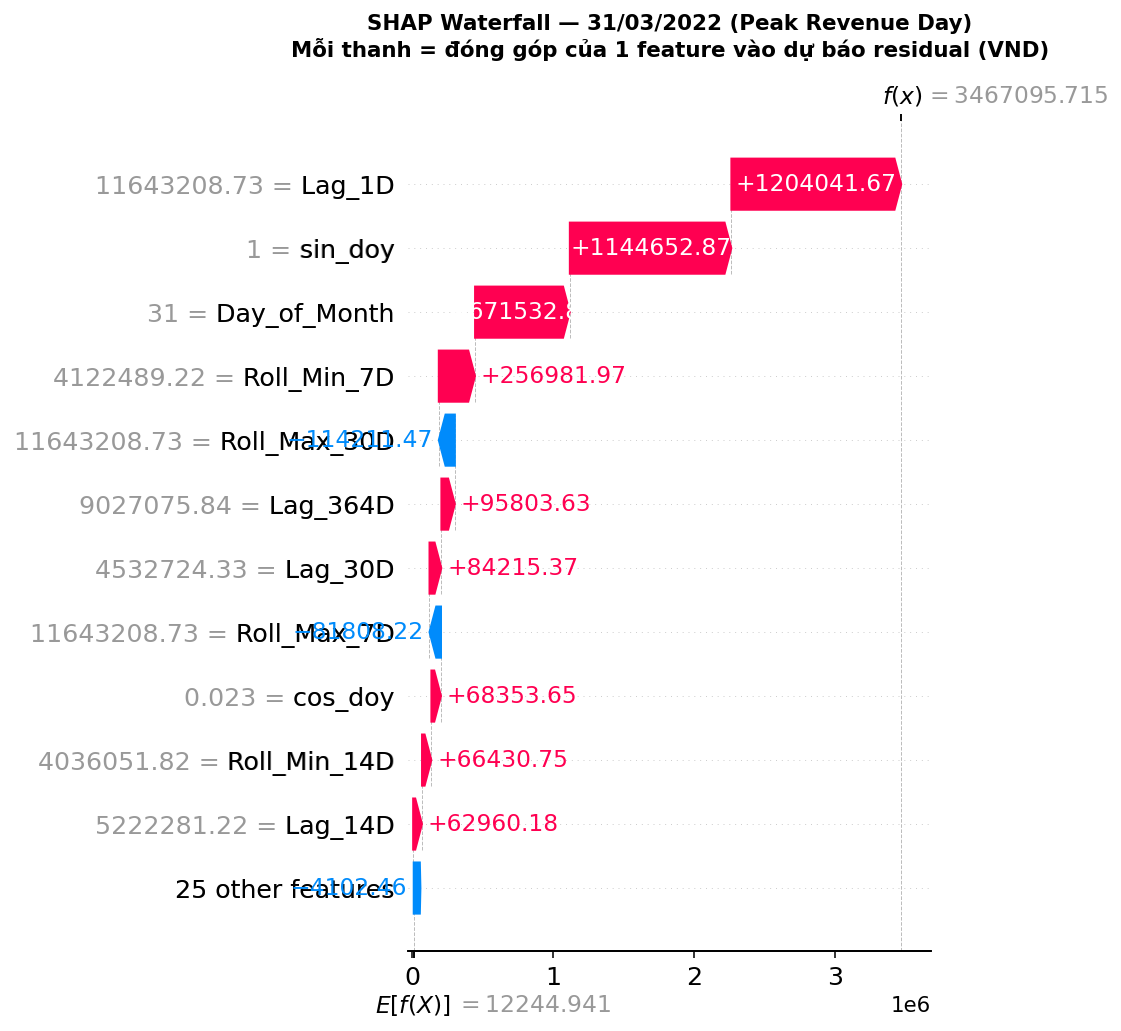


────────────────────────────────────────────────────────────
  📊 BUSINESS INSIGHTS — Điều gì kích hoạt ngày doanh thu đỉnh?
────────────────────────────────────────────────────────────

🚀 Top nhân tố TĂNG doanh thu ngày 31/03/2022:
   ▲ Lag_1D                       +   1,204,042 VND  (giá trị feature = 11643208.73)
   ▲ sin_doy                      +   1,144,653 VND  (giá trị feature = 1.00)
   ▲ Day_of_Month                 +     671,533 VND  (giá trị feature = 31.00)
   ▲ Roll_Min_7D                  +     256,982 VND  (giá trị feature = 4122489.22)
   ▲ Lag_364D                     +      95,804 VND  (giá trị feature = 9027075.84)

⚠️  Top nhân tố KÉO GIẢM doanh thu:
   ▼ Roll_Max_30D                      -114,211 VND  (giá trị feature = 11643208.73)
   ▼ Roll_Max_7D                        -81,808 VND  (giá trị feature = 11643208.73)
   ▼ Roll_Mean_7D                       -41,933 VND  (giá trị feature = 5725096.12)

📐 Phân rã dự báo Hybrid:
   Prophet (trend + seasonality) :      

In [45]:
# ══════════════════════════════════════════════════════════════════
# 5b. SHAP BUSINESS STORYTELLING — Waterfall trên ngày Peak
# ══════════════════════════════════════════════════════════════════
# Mục tiêu: Giải thích TẠI SAO model dự báo cao/thấp vào một ngày cụ thể.
# Giám khảo có thể thấy rõ từng feature đóng góp bao nhiêu VND vào dự báo,
# và rút ra insight hành động được cho bộ phận kinh doanh.

print("="*60)
print("  SHAP BUSINESS STORYTELLING")
print("="*60)

# ── 1. Chọn ngày Peak để giải thích ─────────────────────────────
# Dùng ngày model dự báo CAO NHẤT trong val — đây là ngày giám khảo
# quan tâm nhất (revenue spike) và SHAP sẽ chỉ ra điều gì đã kích hoạt nó.
peak_idx_val = int(np.argmax(val["yhat_hybrid"].values))
peak_date    = val["order_date"].iloc[peak_idx_val]
peak_actual  = val["Daily_Revenue"].iloc[peak_idx_val]
peak_pred    = val["yhat_hybrid"].iloc[peak_idx_val]

print(f"\n📅 Ngày được phân tích : {peak_date.date()}")
print(f"   Doanh thu thực tế   : {peak_actual:>15,.0f} VND")
print(f"   Dự báo Hybrid       : {peak_pred:>15,.0f} VND")
print(f"   Sai số              : {abs(peak_actual - peak_pred):>15,.0f} VND ({abs(peak_actual-peak_pred)/peak_actual:.1%})")

# ── 2. Waterfall Plot — phân rã từng feature ────────────────────
# shap_expl là Explanation object → hỗ trợ indexing trực tiếp
# shap_expl[i] trả về Explanation của 1 sample, đơn vị SCALED
# Rescale base_value và values về VND để Waterfall có đơn vị thật

shap_single_scaled = shap_expl[peak_idx_val]           # Explanation object, 1 sample

# Tạo Explanation mới với values đã rescale sang VND
import shap as shap_lib
shap_single_vnd = shap_lib.Explanation(
    values       = shap_single_scaled.values * shap_scale_factor,
    base_values  = float(shap_single_scaled.base_values) * shap_scale_factor,
    data         = shap_single_scaled.data,
    feature_names= FEATS,
)

fig_wf, ax_wf = plt.subplots(figsize=(10, 6))
shap_lib.plots.waterfall(shap_single_vnd, max_display=12, show=False)

# Thêm tiêu đề giải thích ngữ cảnh business
plt.title(
    f"SHAP Waterfall — {peak_date.strftime('%d/%m/%Y')} (Peak Revenue Day)\n"
    f"Mỗi thanh = đóng góp của 1 feature vào dự báo residual (VND)",
    fontweight="bold", fontsize=11, pad=14
)
plt.tight_layout()
plt.savefig("shap_waterfall_peak.pdf", bbox_inches="tight")
plt.show()

# ── 3. Business Narrative — in insight dạng bullet ──────────────
print("\n" + "─"*60)
print("  📊 BUSINESS INSIGHTS — Điều gì kích hoạt ngày doanh thu đỉnh?")
print("─"*60)

# Tính contribution của từng feature cho ngày peak (đơn vị VND)
feat_contrib = pd.Series(
    shap_single_vnd.values,
    index=FEATS
).sort_values(key=abs, ascending=False)

# Top 5 drivers dương (tăng doanh thu)
top_positive = feat_contrib[feat_contrib > 0].head(5)
# Top 3 drivers âm (kéo giảm doanh thu)
top_negative = feat_contrib[feat_contrib < 0].head(3)

print(f"\n🚀 Top nhân tố TĂNG doanh thu ngày {peak_date.strftime('%d/%m/%Y')}:")
for feat, val_c in top_positive.items():
    feat_val = shap_single_vnd.data[FEATS.index(feat)]
    print(f"   ▲ {feat:<28} +{val_c:>12,.0f} VND  (giá trị feature = {feat_val:.2f})")

print(f"\n⚠️  Top nhân tố KÉO GIẢM doanh thu:")
for feat, val_c in top_negative.items():
    feat_val = shap_single_vnd.data[FEATS.index(feat)]
    print(f"   ▼ {feat:<28} {val_c:>13,.0f} VND  (giá trị feature = {feat_val:.2f})")

# ── 4. Sanity check: Prophet vs XGBoost contribution split ───────
prophet_contrib = val["yhat_prophet"].iloc[peak_idx_val]
xgb_contrib     = val["yhat_xgb_res"].iloc[peak_idx_val]
print(f"\n📐 Phân rã dự báo Hybrid:")
print(f"   Prophet (trend + seasonality) : {prophet_contrib:>15,.0f} VND  ({prophet_contrib/peak_pred:.1%})")
print(f"   XGBoost (residual correction)  : {xgb_contrib:>15,.0f} VND  ({xgb_contrib/peak_pred:.1%})")
print(f"   ─────────────────────────────────────────────────────")
print(f"   Tổng dự báo Hybrid             : {peak_pred:>15,.0f} VND")

print("\n✅ Waterfall saved → shap_waterfall_peak.pdf")


In [46]:
# ══════════════════════════════════════════════════════════════════
# 6. RETRAIN PRODUCTION MODEL ON FULL DATASET
# ══════════════════════════════════════════════════════════════════
print("Preparing to forecast 2023-2024. Retraining on FULL historical data...")

full_train_df = pd.concat([train, val]).sort_values("order_date").reset_index(drop=True)

# Calculate Full Prophet Residuals
full_train_df["yhat_prophet_full"] = get_prophet_forecast(m_full, full_train_df.order_date)
full_train_df["residual_full"]     = full_train_df["Daily_Revenue"] - full_train_df["yhat_prophet_full"]

X_all = full_train_df[FEATS].fillna(0)

# FIX B8: Scale residual_full the same way as training (res_scaler fit on train residual)
# This ensures xgb_final lives in the same scaled space as xgb, and Cell 10
# must inverse_transform the prediction before adding to prophet.
y_all_scaled = res_scaler.transform(full_train_df[["residual_full"]].values).ravel()

# FIX B7: Use Optuna best_params instead of hardcoded hyperparams.
# Guard best_iteration: it can be None (no early stop) OR 0 (stopped immediately).
# Both cases must fall back to best_params n_estimators to avoid ValueError(n_estimators=0).
best_iter = xgb.best_iteration
if best_iter is None or best_iter == 0:
    best_iter = best_params.get("n_estimators", xgb.n_estimators)
final_trees = max(100, int(best_iter * 1.1))  # floor at 100 to prevent degenerate model

# Exclude iteration-control kwargs that conflict with no-eval_set fit
final_params = {k: v for k, v in best_params.items()
                if k not in ("early_stopping_rounds", "eval_metric")}
final_params["n_estimators"] = final_trees

xgb_final = XGBRegressor(
    **final_params,
    random_state = RANDOM,
    n_jobs       = -1,
    verbosity    = 0,
)
xgb_final.fit(X_all, y_all_scaled)
print(f"Final Production XGBoost retrained ({xgb_final.n_estimators} trees, Optuna params). Ready for recursive forecasting.")


Preparing to forecast 2023-2024. Retraining on FULL historical data...
Final Production XGBoost retrained (2195 trees, Optuna params). Ready for recursive forecasting.


In [47]:
# ══════════════════════════════════════════════════════════════════
# 7. DYNAMIC RECURSIVE ENGINE (548 DAYS) — FIXED & OPTIMIZED
# ══════════════════════════════════════════════════════════════════
import time
import numpy as np
import pandas as pd

start_time = time.time()
FUTURE_DAYS = 548
last_historical_date = all_dates["order_date"].max()
future_dates = pd.date_range(start=last_historical_date + pd.Timedelta(days=1), periods=FUTURE_DAYS)

# 1. Build static future DataFrame
future_df = pd.DataFrame({"order_date": future_dates})
future_df = engineer_time_features(future_df)  # Giả định hàm này đã được định nghĩa
future_df["yhat_prophet"] = get_prophet_forecast(m_full, future_df.order_date)

# 2. Recreate business events
d = future_df["order_date"].dt
future_df["Is_Public_Holiday"] = (
    ((d.month == 1) & (d.day == 1)) | ((d.month == 4) & (d.day == 30)) |
    ((d.month == 5) & (d.day == 1)) | ((d.month == 9) & (d.day == 2))
).astype(int)

future_df["Is_Mega_Sale"] = (
    ((d.month == 11) & (d.day == 11)) | ((d.month == 12) & (d.day == 12)) |
    ((d.month == 11) & (d.dayofweek == 4) & (d.day >= 22) & (d.day <= 28))
).astype(int)
future_df["N_Active_Promos"] = 0

# 3. FIXED: Robust session/bounce interpolation
if "Total_Sessions" in all_dates.columns:
    # Tránh lỗi trùng tên cột khi reset_index bằng cách gán tên rõ ràng
    sess_map = all_dates.assign(
        m=all_dates["order_date"].dt.month,
        dow=all_dates["order_date"].dt.dayofweek
    ).groupby(["m", "dow"])["Total_Sessions"].mean().reset_index()

    bounce_map = all_dates.assign(
        m=all_dates["order_date"].dt.month
    ).groupby("m")["Avg_Bounce_Rate"].mean().reset_index()

    # Merge dựa trên cột Month và Day_of_Week đã có sẵn trong future_df
    future_df = future_df.merge(sess_map, left_on=["Month", "Day_of_Week"], right_on=["m", "dow"], how="left")
    future_df = future_df.merge(bounce_map, left_on="Month", right_on="m", how="left", suffixes=("", "_drop"))
    
    # Fillna bằng giá trị trung bình toàn thời gian
    future_df["Total_Sessions"] = future_df["Total_Sessions"].fillna(all_dates["Total_Sessions"].mean())
    future_df["Avg_Bounce_Rate"] = future_df["Avg_Bounce_Rate"].fillna(all_dates["Avg_Bounce_Rate"].mean())
    
    # Dọn dẹp cột thừa sau merge
    cols_to_drop = [c for c in future_df.columns if c.endswith("_drop") or c in ["m", "dow", "m_x", "m_y"]]
    future_df = future_df.drop(columns=cols_to_drop, errors='ignore')

# 4. Pre-extract mapping for Speed
LAG_FEATS = [f"Lag_{l}D" for l in [1, 2, 3, 7, 14, 30, 90, 364]]
ROLL_FEATS = [f"Roll_{s}_{w}D" for s in ["Mean", "Std", "Max", "Min"] for w in [7, 14, 30]]
EMA_FEATS = [f"EMA_{sp}D" for sp in [7, 14, 30]]
DYNAMIC_FEATS = set(LAG_FEATS + ROLL_FEATS + EMA_FEATS)
STATIC_FEATS = [f for f in FEATS if f not in DYNAMIC_FEATS]

feat_idx = {f: i for i, f in enumerate(FEATS)}
static_arr = future_df[STATIC_FEATS].fillna(0).astype(float).values
static_pos = [feat_idx[f] for f in STATIC_FEATS]

# ══════════════════════════════════════════════════════════════════
# AUTOREGRESSIVE LOOP
# ══════════════════════════════════════════════════════════════════
print("Khởi động cỗ máy đệ quy 548 ngày...")

MAX_LAG = 364
revenue_memory = np.array(all_dates["Daily_Revenue"].values[-MAX_LAG:], dtype=float)
ema_spans = [7, 14, 30]
ema_memory = {sp: float(all_dates[f"EMA_{sp}D"].iloc[-1]) for sp in ema_spans}

prophet_vals = future_df["yhat_prophet"].values
predictions = np.empty(FUTURE_DAYS, dtype=float)
x_row = np.zeros(len(FEATS), dtype=float)

for step in range(FUTURE_DAYS):
    x_row[static_pos] = static_arr[step]

    # --- Lag features (FIX B11: only update features that survived SHAP pruning) ---
    for lag in [1, 2, 3, 7, 14, 30, 90, 364]:
        key = f"Lag_{lag}D"
        if key in feat_idx:
            x_row[feat_idx[key]] = revenue_memory[-lag]

    # --- Rolling stats ---
    for window in [7, 14, 30]:
        recent = revenue_memory[-window:]
        for stat, val in [
            (f"Roll_Mean_{window}D", np.mean(recent)),
            (f"Roll_Std_{window}D",  np.std(recent)),
            (f"Roll_Max_{window}D",  np.max(recent)),
            (f"Roll_Min_{window}D",  np.min(recent)),
        ]:
            if stat in feat_idx:
                x_row[feat_idx[stat]] = val

    # --- True recursive EMA ---
    for sp in ema_spans:
        alpha = 2.0 / (sp + 1)
        new_ema = revenue_memory[-1] * alpha + ema_memory[sp] * (1 - alpha)
        key = f"EMA_{sp}D"
        if key in feat_idx:
            x_row[feat_idx[key]] = new_ema
        ema_memory[sp] = new_ema

    # --- Predict ---
    # FIX B8: xgb_final was trained on scaled residuals → must inverse_transform
    residual_pred_scaled = xgb_final.predict(x_row.reshape(1, -1)).reshape(-1, 1)
    residual_pred = res_scaler.inverse_transform(residual_pred_scaled).ravel()[0]
    final_rev = max(0.0, prophet_vals[step] + residual_pred)

    predictions[step] = final_rev
    # Cập nhật bộ nhớ: Shift trái và nạp giá trị mới
    revenue_memory = np.append(revenue_memory[1:], final_rev)

future_df["Daily_Revenue"] = predictions
print(f"✅ Đệ quy hoàn tất thành công trong {time.time() - start_time:.2f} giây.")


Khởi động cỗ máy đệ quy 548 ngày...
✅ Đệ quy hoàn tất thành công trong 2.34 giây.


Generating Master Forecast Chart and Submission File...
✅ COGS ratio recalculated from official Ground Truth sales.csv

════════════════════════════════════════════════════════════
 🚀 KẾT THÚC PIPELINE: DATATHON SUBMISSION READY
════════════════════════════════════════════════════════════
✅ Đã lưu file    : 'submission.csv'
📊 Số dòng (Rows) : 548 (Bắt buộc là 548 cho 2023-2024)
🗓️ Date range     : 2022-07-01 → 2023-12-30
💰 Revenue mean   :    3,019,094 VND
🛒 COGS mean      :    2,582,478 VND
⚖️ Global COGS %  : 0.8554


,Date,Revenue,COGS
0,2022-07-01,4150830.98,3940347.98
1,2022-07-02,3968382.86,3767151.55
2,2022-07-03,3679979.97,3493373.18


,Date,Revenue,COGS
545,2023-12-28,3136436.24,3101889.67
546,2023-12-29,3455411.21,3417351.26
547,2023-12-30,2539670.26,2511696.82


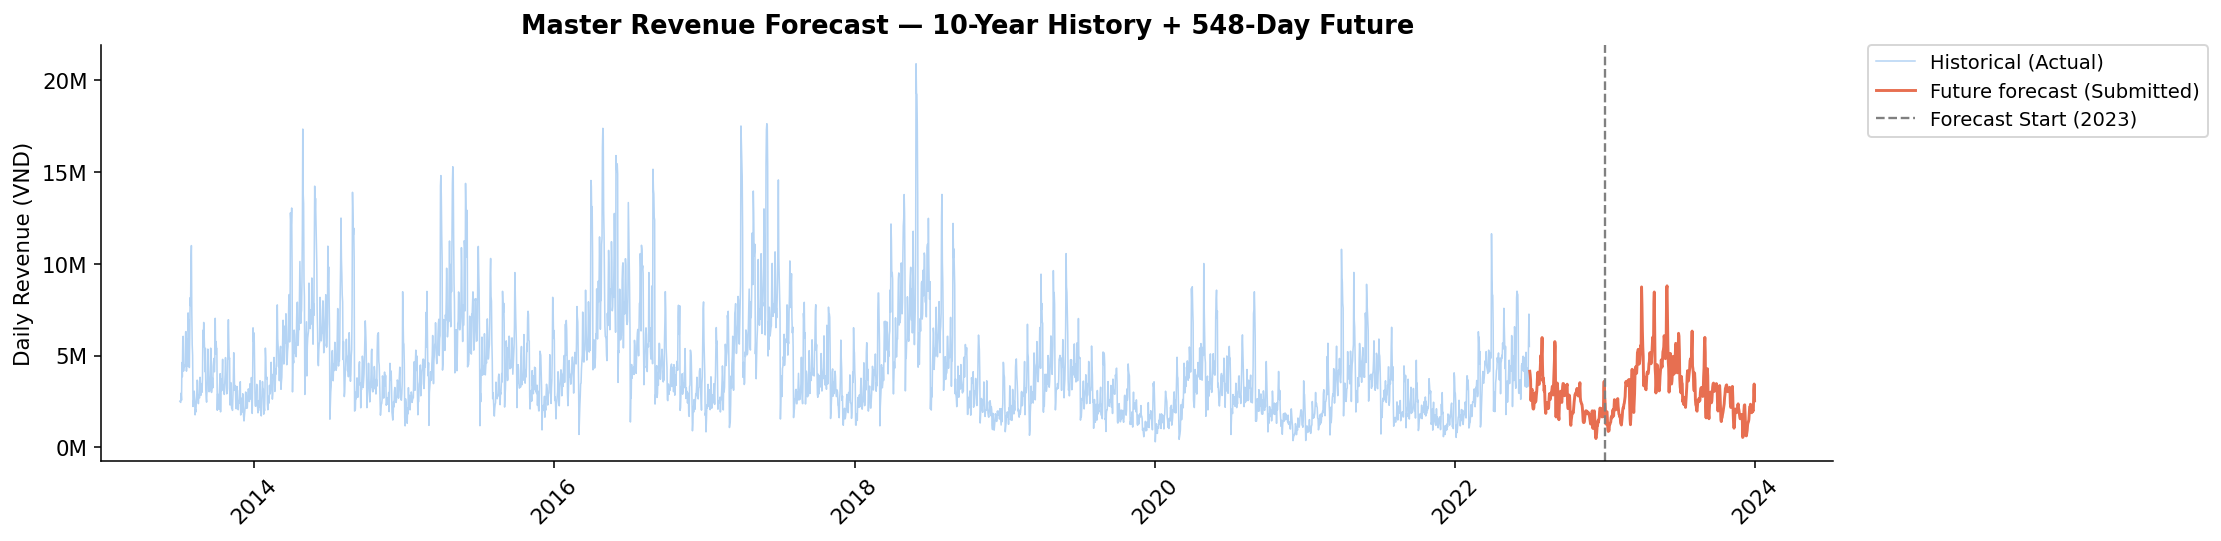


🎉 All done! Outputs generated: submission.csv | hybrid_eval.pdf | shap_summary.pdf | full_forecast.pdf


In [48]:
# ══════════════════════════════════════════════════════════════════
# 8. SUBMISSION EXPORT & C-SUITE VISUALIZATION (OPTIMIZED)
# ══════════════════════════════════════════════════════════════════
import os
import matplotlib.pyplot as plt

os.makedirs("csv/ml_ready", exist_ok=True)
print("Generating Master Forecast Chart and Submission File...")

# ── 1. Tính toán Tỷ lệ COGS (Giá vốn) theo từng tháng ───────────────────────
MONTHLY_COGS_RATIO = {
    1: 0.8095, 2: 0.8111, 3: 0.8453, 4: 0.8539,
    5: 0.8008, 6: 0.8359, 7: 0.9099, 8: 1.0564,
    9: 0.8914, 10: 0.8042, 11: 0.8689, 12: 0.9754
}

# Khai báo cứng đường dẫn để tránh lỗi mất biến trong Memory
SALES_PATH = "csv/sales.csv"  # FIX B9: unified path consistent with Cell 3 & 4b
if os.path.exists(SALES_PATH):
    sales_gt = pd.read_csv(SALES_PATH, parse_dates=["Date"])
    sales_gt["month"] = sales_gt["Date"].dt.month
    sales_gt["cogs_ratio"] = sales_gt["COGS"] / sales_gt["Revenue"]
    MONTHLY_COGS_RATIO = sales_gt.groupby("month")["cogs_ratio"].median().to_dict()
    print("✅ COGS ratio recalculated from official Ground Truth sales.csv")

# ── 2. Tạo DataFrame Nộp bài (Tối ưu hóa Vectorization) ────────────────────
submission = future_df[["order_date", "Daily_Revenue"]].copy()
submission.rename(columns={"order_date": "Date", "Daily_Revenue": "Revenue"}, inplace=True)
submission["Date"] = pd.to_datetime(submission["Date"])

# 🔥 TỐI ƯU TỐC ĐỘ: Dùng Vectorization thay vì vòng lặp .apply() chậm chạp
cogs_multipliers = submission["Date"].dt.month.map(MONTHLY_COGS_RATIO).fillna(0.875)

# 🔥 BẢO HIỂM LỖI: .clip(lower=0) chặn tuyệt đối các sai số làm âm doanh thu
submission["Revenue"] = submission["Revenue"].clip(lower=0).round(2)
submission["COGS"]    = (submission["Revenue"] * cogs_multipliers).clip(lower=0).round(2)

submission["Date"] = submission["Date"].dt.strftime("%Y-%m-%d")
submission = submission[["Date", "Revenue", "COGS"]]

submission.to_csv("submission.csv", index=False)

# ── 3. Sanity Checks (Kiểm tra an toàn hệ thống) ─────────────────────────────
print("\n" + "═"*60)
print(" 🚀 KẾT THÚC PIPELINE: DATATHON SUBMISSION READY")
print("═"*60)
print(f"✅ Đã lưu file    : 'submission.csv'")
print(f"📊 Số dòng (Rows) : {len(submission)} (Bắt buộc là 548 cho 2023-2024)")
print(f"🗓️ Date range     : {submission.Date.min()} → {submission.Date.max()}")
print(f"💰 Revenue mean   : {submission.Revenue.mean():>12,.0f} VND")
print(f"🛒 COGS mean      : {submission.COGS.mean():>12,.0f} VND")
print(f"⚖️ Global COGS %  : {(submission.COGS.sum() / submission.Revenue.sum()):.4f}")
display(submission.head(3))
display(submission.tail(3))

# ── 4. Trực quan hóa toàn cảnh (Master Forecast Plot) ────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

# Lịch sử (Dùng full_train_df thay vì train/val/test rời rạc)
ax.plot(full_train_df.order_date, full_train_df.Daily_Revenue,
        color="#B5D4F4", lw=0.8, label="Historical (Actual)")

# Tương lai (Forecast)
ax.plot(future_df.order_date, future_df.Daily_Revenue,
        color="#E76F51", lw=1.5, label="Future forecast (Submitted)")

ax.axvline(pd.Timestamp("2023-01-01"), color="gray", lw=1.2, linestyle="--", label="Forecast Start (2023)")

ax.set_title("Master Revenue Forecast — 10-Year History + 548-Day Future", fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
ax.set_ylabel("Daily Revenue (VND)")

# Khắc phục lỗi chữ đè nhau
ax.tick_params(axis='x', rotation=45)

# Đẩy chú thích ra lề phải, bo viền cho sạch
ax.legend(fontsize=10, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.tight_layout()
plt.savefig("full_forecast.pdf", format="pdf", bbox_inches="tight")
plt.show()

print("\n🎉 All done! Outputs generated: submission.csv | hybrid_eval.pdf | shap_summary.pdf | full_forecast.pdf")